# Libraries

In [ ]:
! pip install catboost

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score
from scipy.ndimage import rotate
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Stress generators


In [ ]:
def create_canvas_dataset(images, canvas_size=56, random_shift=False):
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28 + 1)
            v_off = np.random.randint(0, canvas_size - 28 + 1)
        else:
            h_off, v_off = (canvas_size - 28) // 2, (canvas_size - 28) // 2
        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
    return dataset

def apply_permutation(images_flat):
    np.random.seed(42)
    perm_indices = np.random.permutation(images_flat.shape[1])
    return images_flat[:, perm_indices]

def apply_occlusion(images, patch_size=12):
    occluded = images.copy()
    canvas_size = images.shape[1]
    np.random.seed(24)
    for img in occluded:
        x = np.random.randint(10, canvas_size - patch_size - 10)
        y = np.random.randint(10, canvas_size - patch_size - 10)
        img[y:y+patch_size, x:x+patch_size] = 0
    return occluded

def apply_rotation(images, angle=45):
    rotated = np.zeros_like(images)
    for i in range(len(images)):
        rotated[i] = rotate(images[i], angle, reshape=False, order=1)
    return np.clip(rotated, 0, 1)

def apply_contrast(images, alpha=0.4):
    cont = np.zeros_like(images)
    for i in range(len(images)):
        img_mean = np.mean(images[i])
        cont[i] = img_mean + alpha * (images[i] - img_mean)
    return np.clip(cont, 0, 1)


train_samples, test_samples, canvas = 10000, 2000, 56
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train, y_train = x_train[:train_samples] / 255.0, y_train[:train_samples]
x_test, y_test = x_test[:test_samples] / 255.0, y_test[:test_samples]

X_train_base = create_canvas_dataset(x_train, canvas, random_shift=False)
X_test_base = create_canvas_dataset(x_test, canvas, random_shift=False)

test_conds = {
    'Baseline': X_test_base,
    'Shifted': create_canvas_dataset(x_test, canvas, random_shift=True),
    'Rotated': apply_rotation(X_test_base, angle=45),
    'Contrast': apply_contrast(X_test_base, alpha=0.4),
    'Permuted': apply_permutation(X_test_base.reshape(-1, canvas*canvas)).reshape(-1, canvas, canvas),
    'Occluded': apply_occlusion(X_test_base)
}

flat_dim = canvas * canvas

trained_models = {}
master_results = {}
precomputed_test_features = {}

print(f"Data ready! Train shape: {X_train_base.shape}")

Data ready! Train shape: (10000, 56, 56)


# Training

## CNN

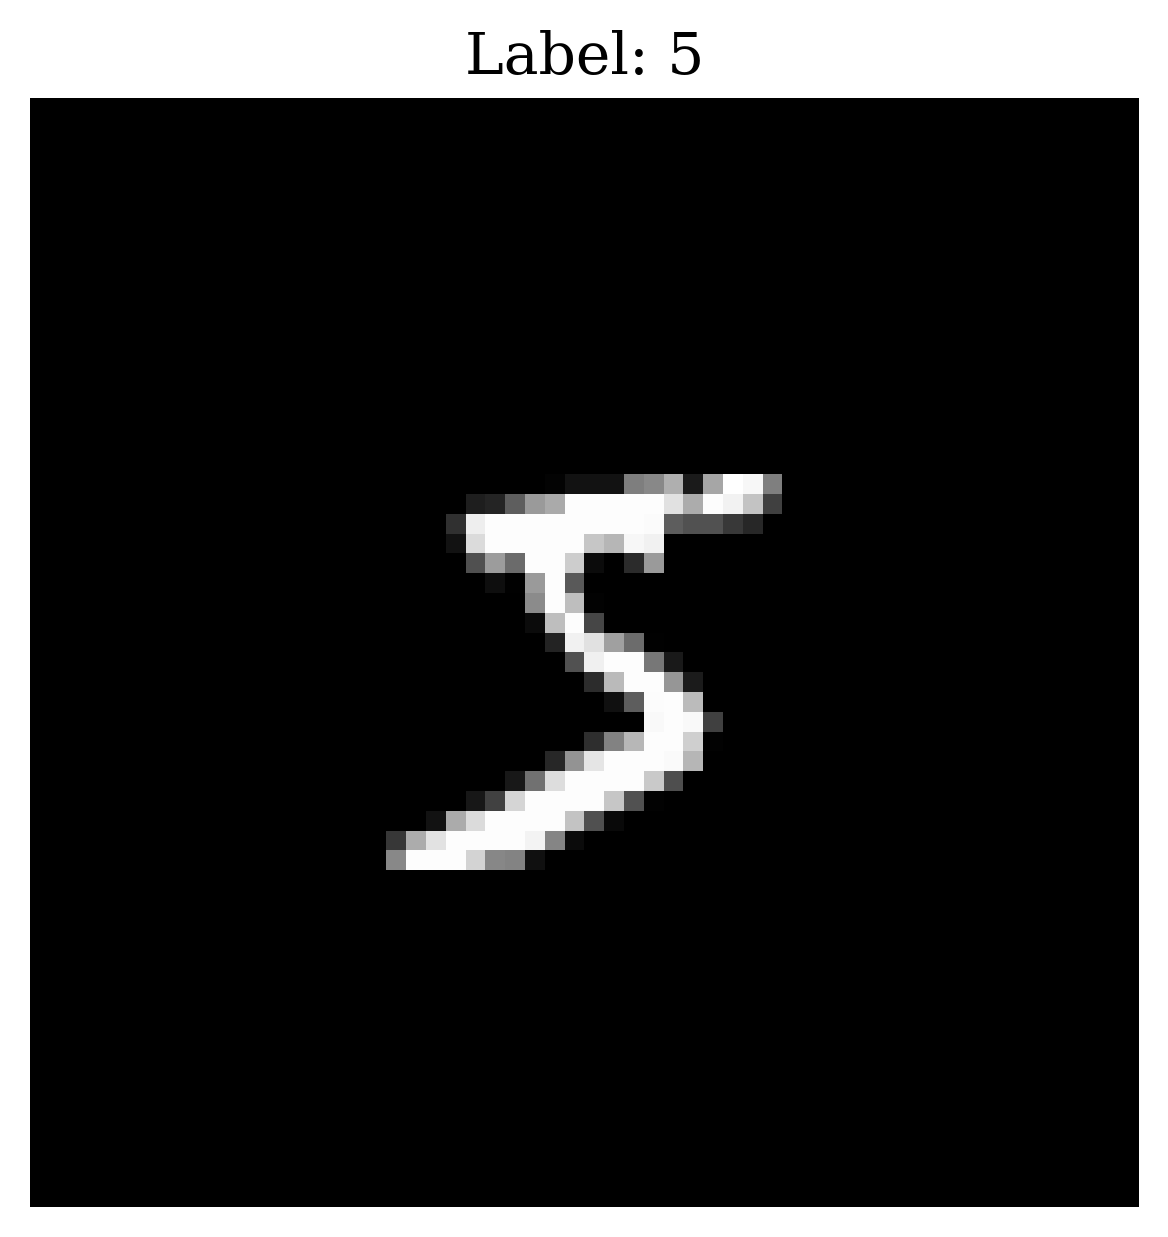

In [ ]:
import matplotlib.pyplot as plt

# Look at the exact array going into the CNN
sample_image = X_train_base.reshape(-1, 56, 56, 1)[0]

plt.imshow(sample_image[:, :, 0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [ ]:
# Core model
canvas= 56
core_input = layers.Input(shape=(canvas, canvas, 1), name="core_input")

# Block 1
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(core_input)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2,2))(x)
x = layers.Dropout(0.2)(x)

# Block 2
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2,2))(x)
x = layers.Dropout(0.3)(x)

# Feature extraction target (Flattening provides structural data for Boosting)
features = layers.Flatten()(x)
dense_feats = layers.Dense(128, activation="relu", name="dense_features")(features)

# Classifier head
outputs = layers.Dense(10, activation="softmax")(dense_feats)

core_model = Model(inputs=core_input, outputs=outputs, name="core_cnn")



# Training wrappers and augmentation (aplied during fit)
train_input = layers.Input(shape=(canvas, canvas, 1), name="train_input")
aug = layers.RandomRotation(factor=0.1, fill_mode='reflect')(train_input)
aug = layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode='reflect')(aug)

# Pass the augmented images through the core model
train_outputs = core_model(aug)

cnn_model = Model(inputs=train_input, outputs=train_outputs, name="training_wrapper")

# Compile and train
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
cnn_model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("Training CNN...")
cnn_model.fit(
    X_train_base.reshape(-1, canvas, canvas, 1), # Ensure 4D shape
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)
trained_models['CNN (Native)'] = cnn_model

feature_extractor = Model(
    inputs=core_model.input,
    outputs=core_model.get_layer("dense_features").output
)

def get_custom_cnn_features(image_data):
    # Ensure 4D shape (Samples, Height, Width, Channels)
    if len(image_data.shape) == 3:
        image_data = image_data[..., np.newaxis]

    # Dynamically match the input canvas size if necessary
    if image_data.shape[1:3] != (canvas, canvas):
        image_data = tf.image.resize(image_data, [canvas, canvas]).numpy()

    # Extract features
    features = feature_extractor.predict(image_data, batch_size=128, verbose=0)

    return features

Training CNN...
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.4374 - loss: 1.7473 - val_accuracy: 0.1040 - val_loss: 2.5079
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7264 - loss: 0.8435 - val_accuracy: 0.3950 - val_loss: 1.9980
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8128 - loss: 0.5689 - val_accuracy: 0.6260 - val_loss: 1.2678
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8642 - loss: 0.4282 - val_accuracy: 0.9080 - val_loss: 0.3851
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8906 - loss: 0.3472 - val_accuracy: 0.9630 - val_loss: 0.1241
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9037 - loss: 0.3032 - val_accuracy: 0.9730 - val_loss: 0.0973
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9159 - loss: 0.2754 - val_accuracy: 0.9600 - val_loss: 0.1211
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9252 - loss: 

## Raw Boost

In [ ]:
X_train_flat = X_train_base.reshape(-1, flat_dim)

xgb_raw = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist', n_jobs=-1)
print("  -> Fitting XGBoost (Raw)...")
xgb_raw.fit(X_train_flat, y_train)
trained_models['XGBoost (Raw)'] = xgb_raw

lgb_raw = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1, n_jobs=-1)
print("  -> Fitting LightGBM (Raw)...")
lgb_raw.fit(X_train_flat, y_train)
trained_models['LightGBM (Raw)'] = lgb_raw

cb_raw = CatBoostClassifier(n_estimators=100, learning_rate=0.1, verbose=0,
thread_count=-1)
print("  -> Fitting CatBoost (Raw)...")
cb_raw.fit(X_train_flat, y_train)
trained_models['CatBoost (Raw)'] = cb_raw

  -> Fitting XGBoost (Raw)...
  -> Fitting LightGBM (Raw)...
  -> Fitting CatBoost (Raw)...


## Hybrid Boost

In [ ]:
print("  -> Extracting CNN Features for Training Data...")
X_train_features = get_custom_cnn_features(X_train_base)

# Force the dictionary to reset so test features always match training features
precomputed_test_features = {}

if not precomputed_test_features:
    for cond_name, X_test in test_conds.items():
        print(f"  -> Extracting CNN Features for {cond_name} Test Data...")
        precomputed_test_features[cond_name] = get_custom_cnn_features(X_test)

xgb_hybrid = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist', n_jobs=-1)
print("  -> Fitting XGBoost (CNN Feat)...")
xgb_hybrid.fit(X_train_features, y_train)
trained_models['XGBoost (CNN Feat)'] = xgb_hybrid

lgb_hybrid = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1, n_jobs=-1)
print("  -> Fitting LightGBM (CNN Feat)...")
lgb_hybrid.fit(X_train_features, y_train)
trained_models['LightGBM (CNN Feat)'] = lgb_hybrid

cb_hybrid = CatBoostClassifier(n_estimators=100, learning_rate=0.1, verbose=0, thread_count=-1)
print("  -> Fitting CatBoost (CNN Feat)...")
cb_hybrid.fit(X_train_features, y_train)
trained_models['CatBoost (CNN Feat)'] = cb_hybrid

  -> Extracting CNN Features for Training Data...
  -> Extracting CNN Features for Baseline Test Data...
  -> Extracting CNN Features for Shifted Test Data...
  -> Extracting CNN Features for Rotated Test Data...
  -> Extracting CNN Features for Contrast Test Data...
  -> Extracting CNN Features for Permuted Test Data...
  -> Extracting CNN Features for Occluded Test Data...
  -> Fitting XGBoost (CNN Feat)...
  -> Fitting LightGBM (CNN Feat)...
  -> Fitting CatBoost (CNN Feat)...


# Evaluation

In [ ]:
for name, model in trained_models.items():
    print(f"  -> Evaluating {name}...")
    master_results[name] = {}

    for cond_name, X_test in test_conds.items():
        current_y_test = y_test[:len(X_test)]
        if "Native" in name:
            _, acc = model.evaluate(X_test.reshape(-1, canvas, canvas, 1), current_y_test, verbose=0)
        elif "Raw" in name:
            acc = accuracy_score(current_y_test, model.predict(X_test.reshape(-1, flat_dim)))
        elif "Feat" in name:
            acc = accuracy_score(current_y_test, model.predict(precomputed_test_features[cond_name]))

        master_results[name][cond_name] = acc

  -> Evaluating CNN (Native)...
  -> Evaluating XGBoost (Raw)...
  -> Evaluating LightGBM (Raw)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  -> Evaluating CatBoost (Raw)...
  -> Evaluating XGBoost (CNN Feat)...
  -> Evaluating LightGBM (CNN Feat)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  -> Evaluating CatBoost (CNN Feat)...


# Ploting

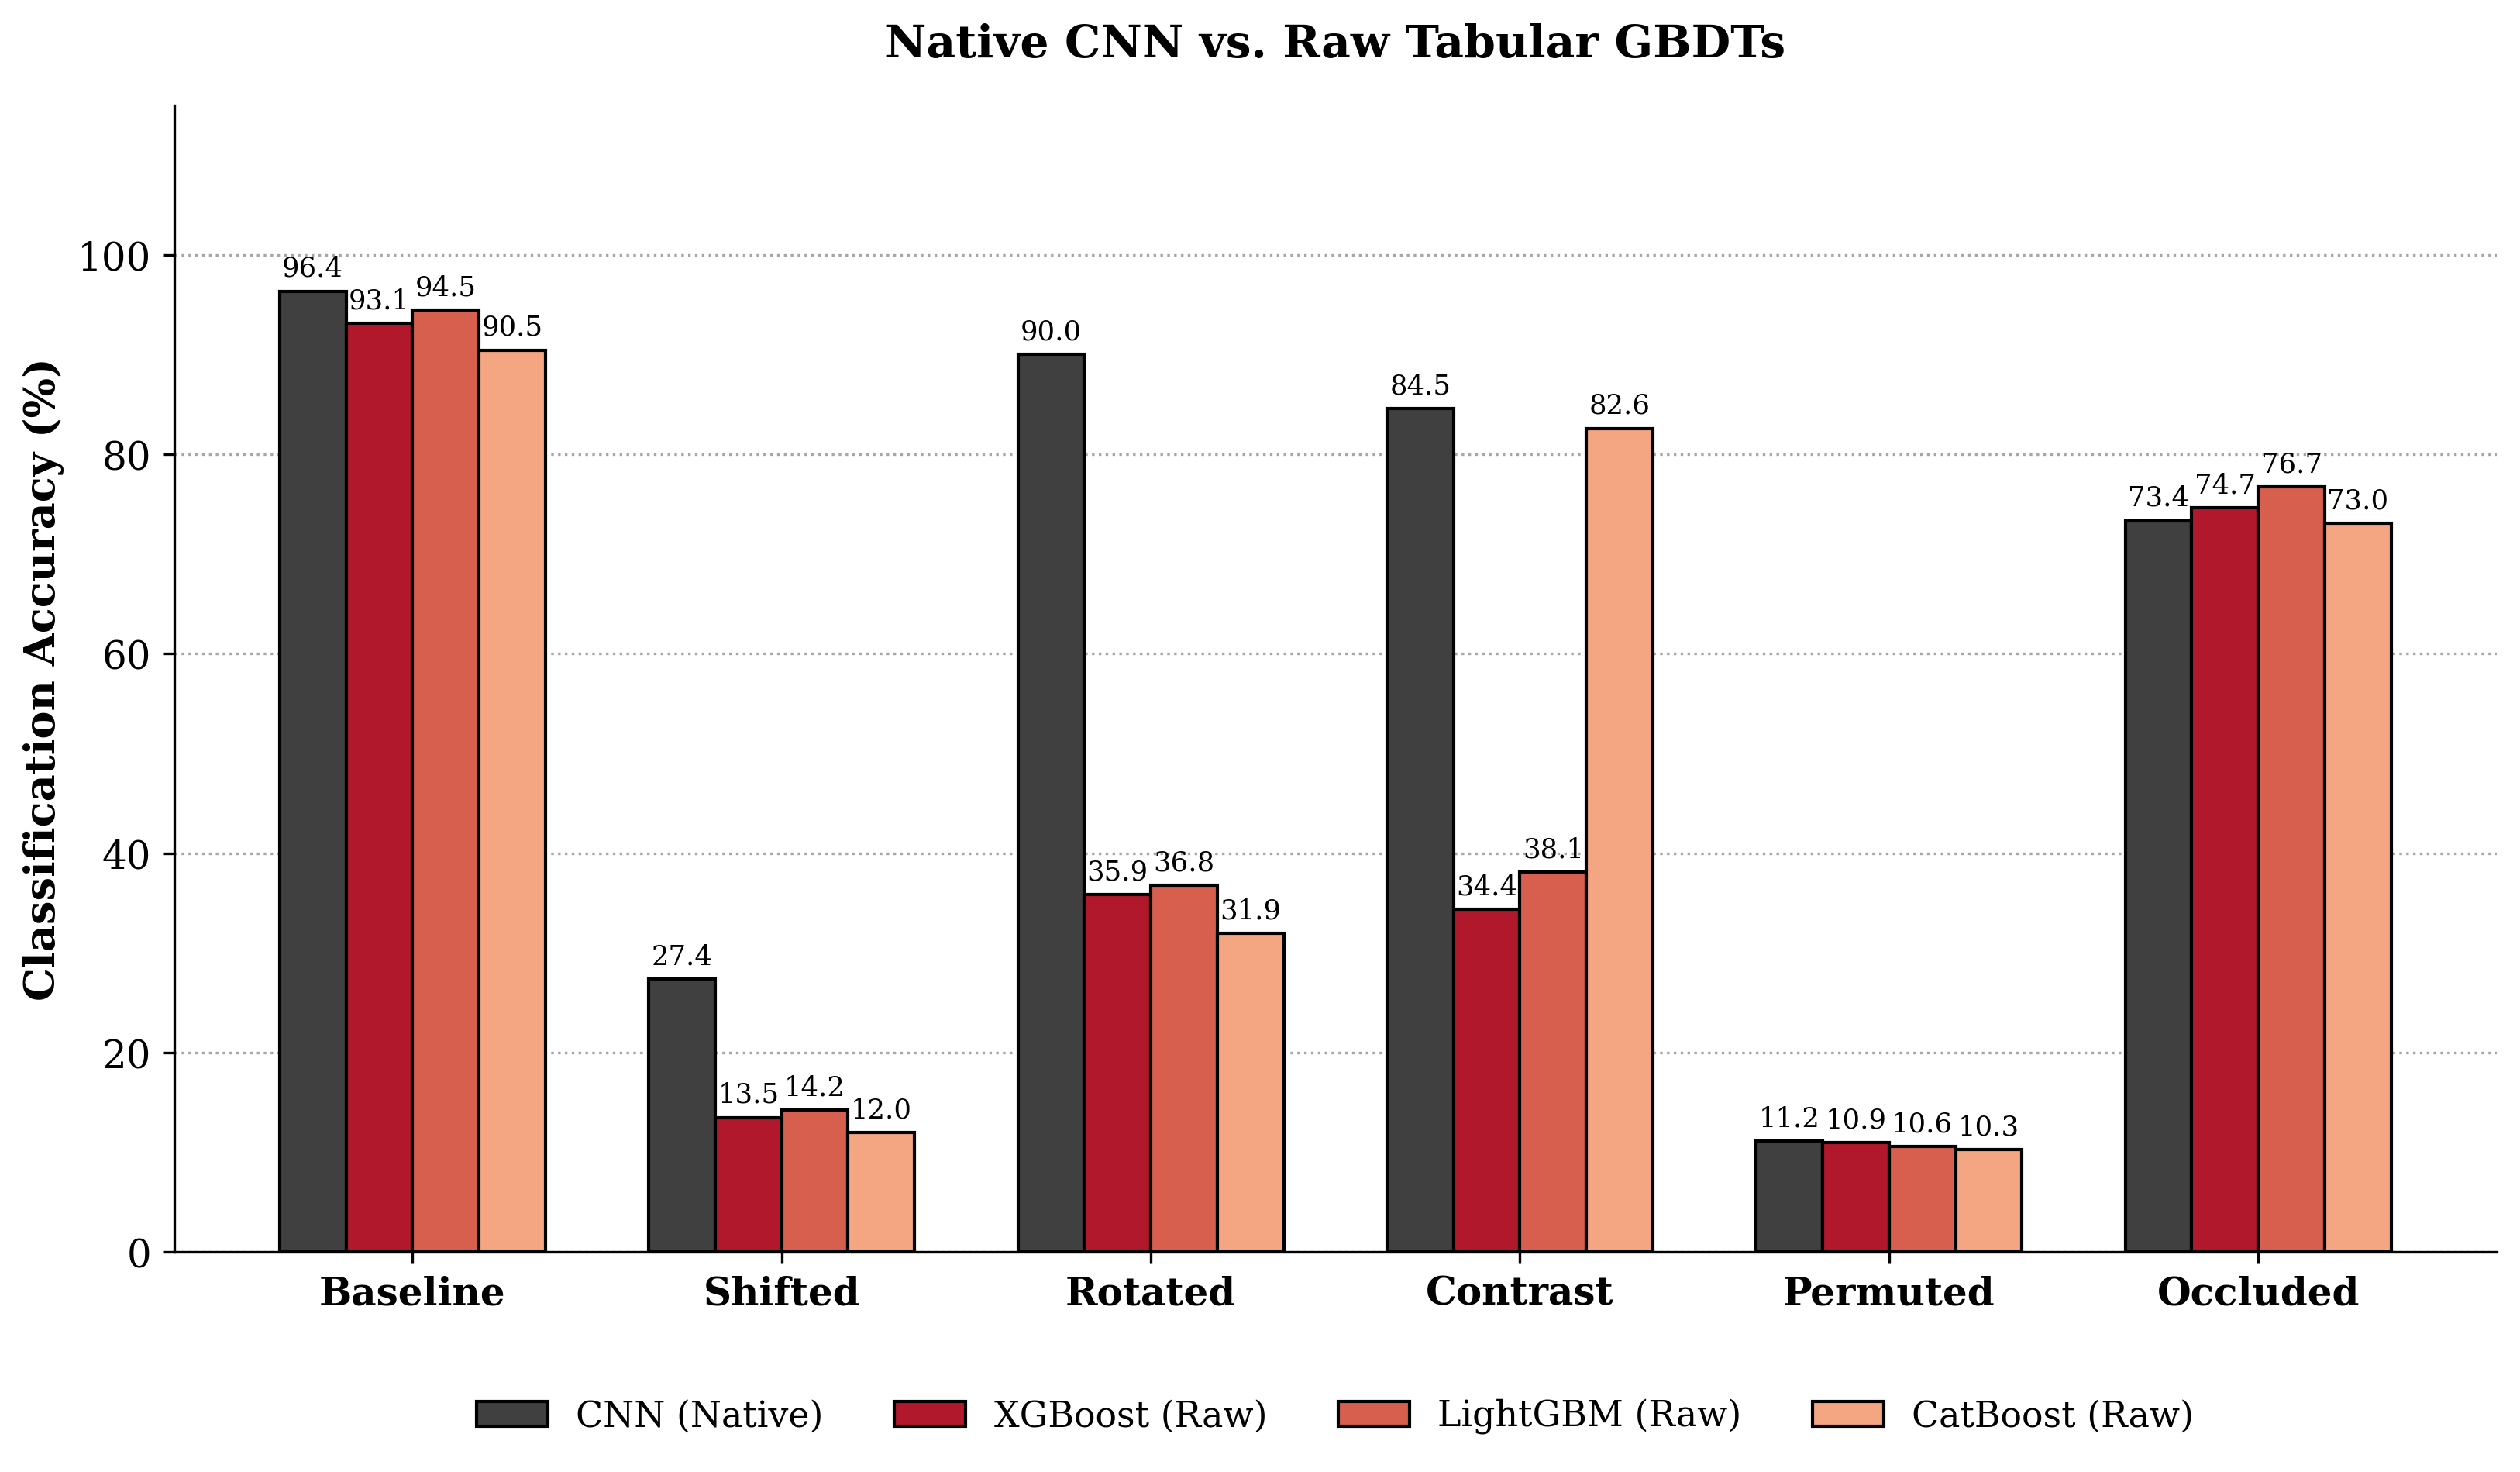

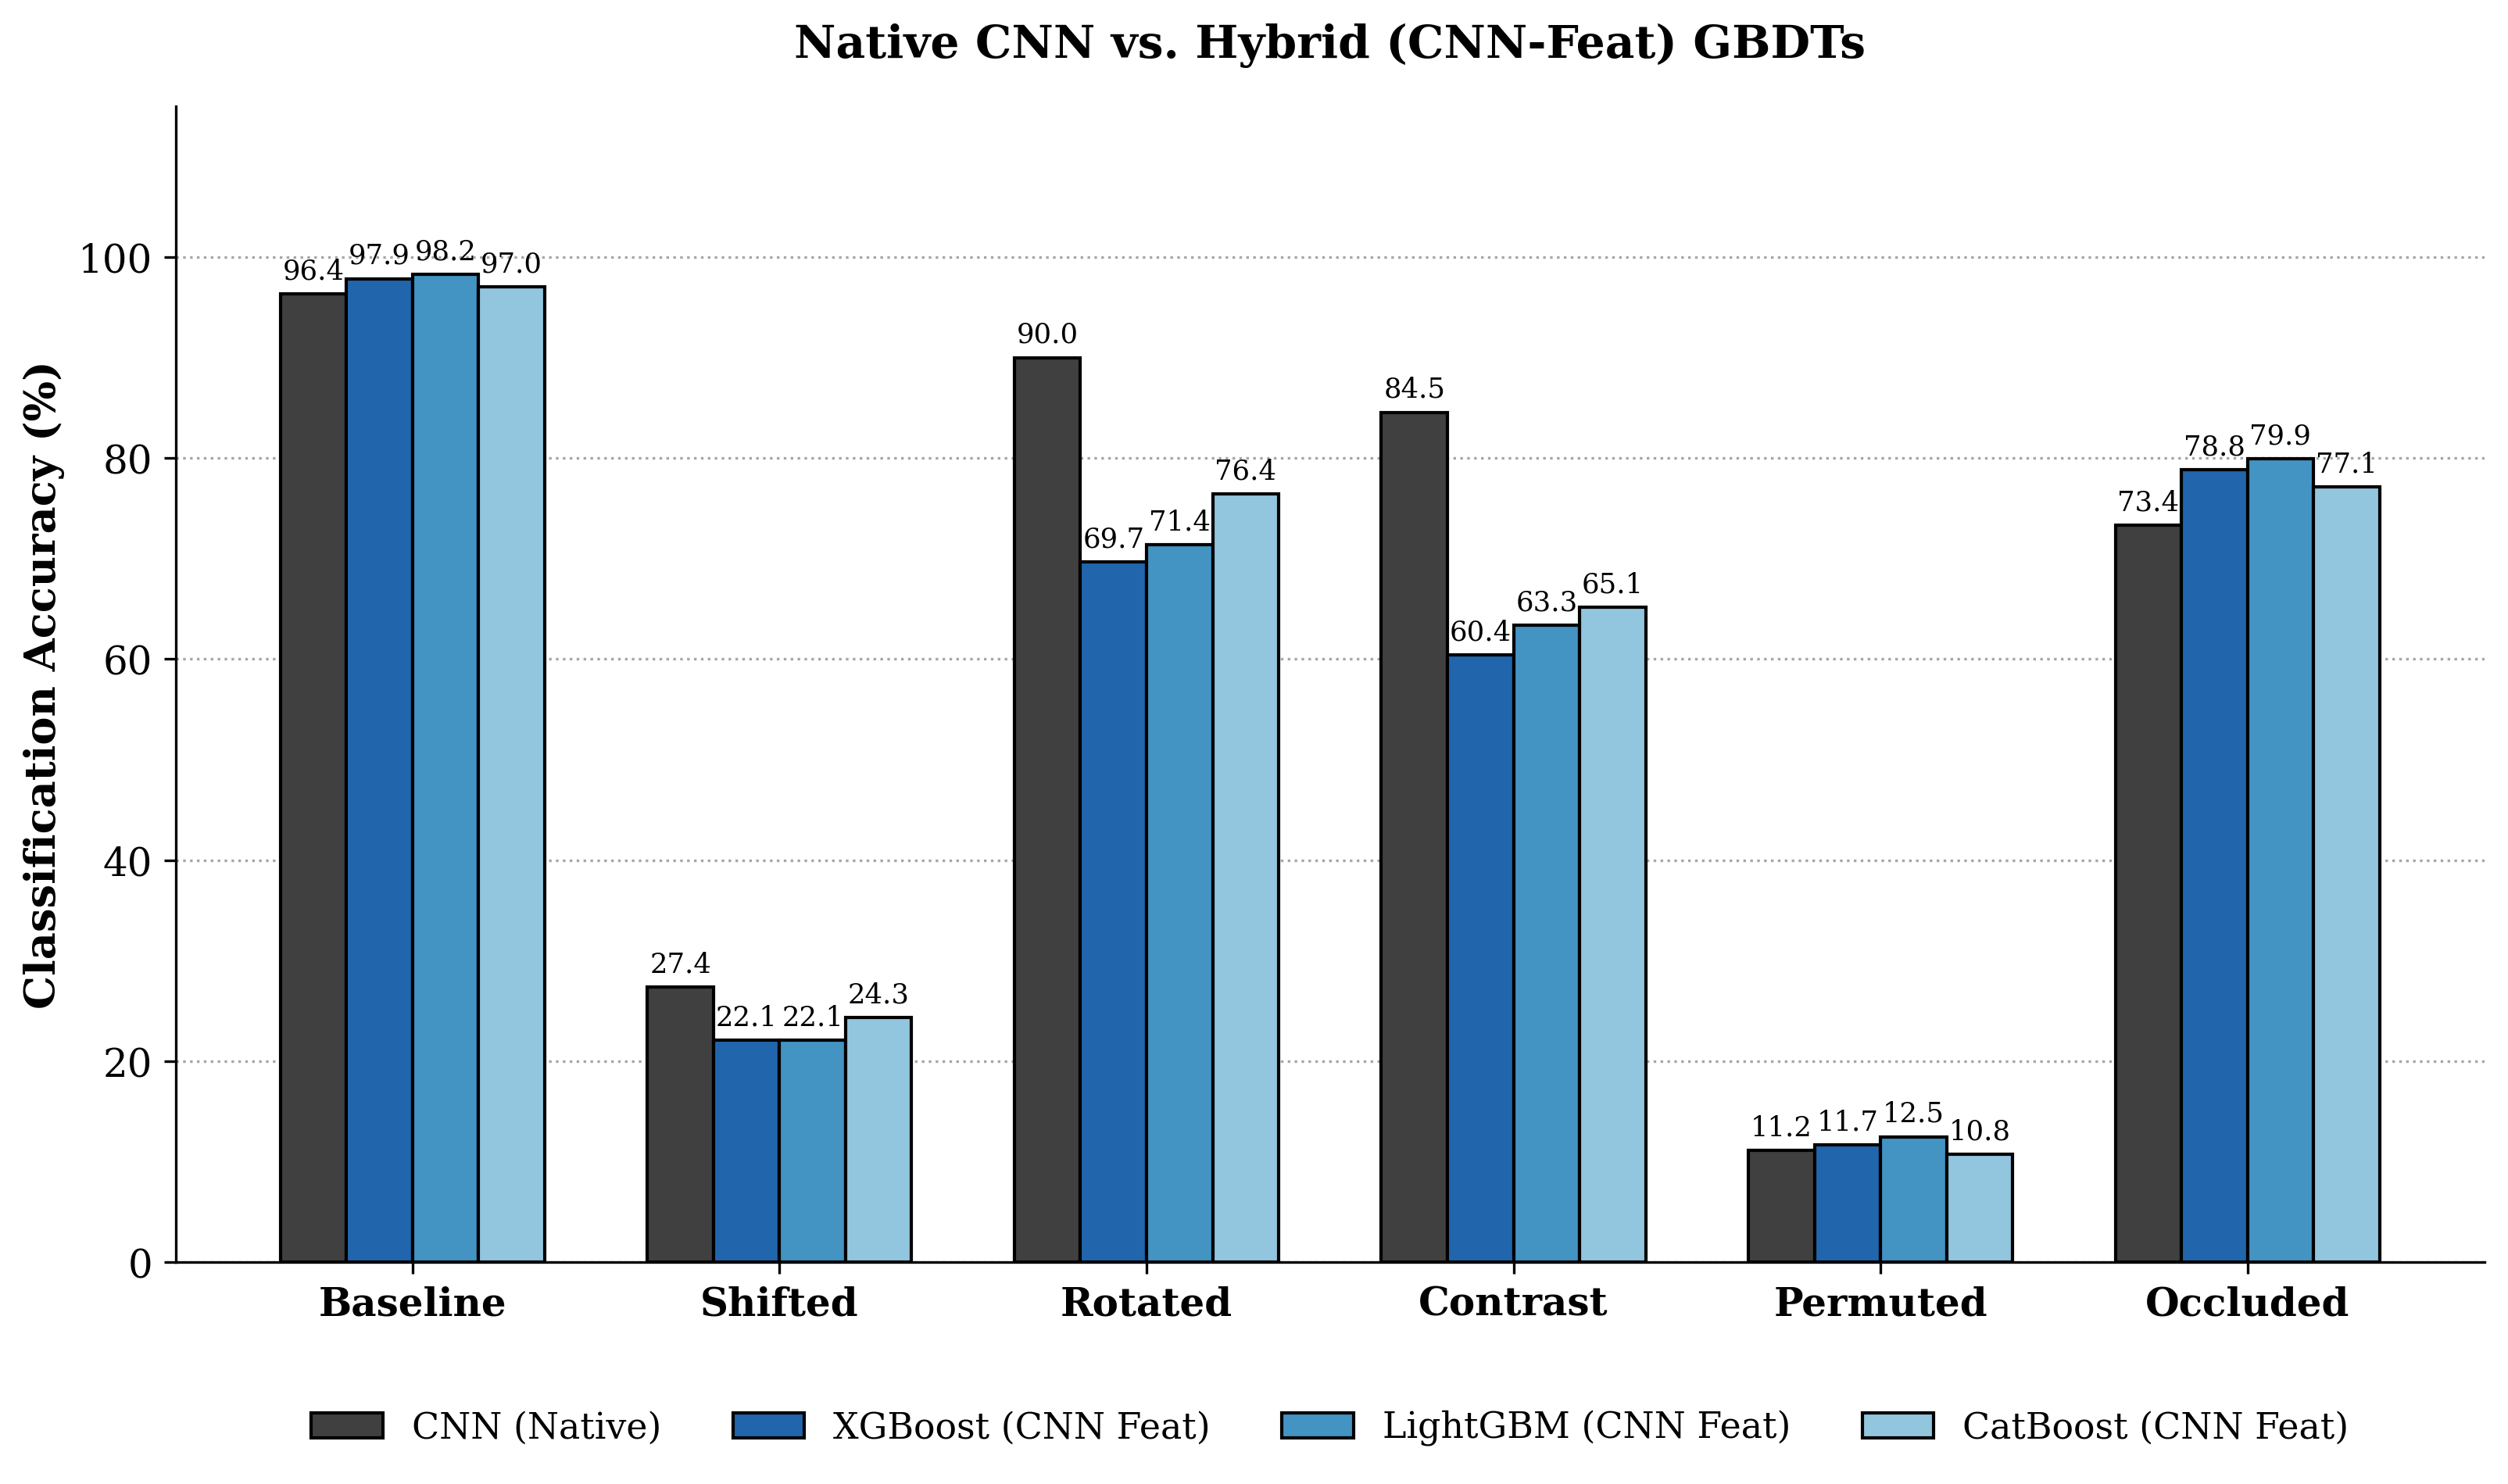

In [ ]:
def draw_publication_separated_plots(results):

    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14,
        'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
    })

    models_in_results = list(results.keys())
    conditions = list(results[models_in_results[0]].keys())

    x = np.arange(len(conditions))
    width = 0.18 # Adjusted width for 6 X-axis items

    color_map = {
        'CNN (Native)': '#404040',
        'XGBoost (Raw)': '#B2182B', 'LightGBM (Raw)': '#D6604D', 'CatBoost (Raw)': '#F4A582',
        'XGBoost (CNN Feat)': '#2166AC', 'LightGBM (CNN Feat)': '#4393C3', 'CatBoost (CNN Feat)': '#92C5DE'
    }

    def add_value_labels(ax):
        for rect in ax.patches:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8.5, color='black', rotation=0)


    fig1, ax1 = plt.subplots(figsize=(11, 6.5))

    group1 = ['CNN (Native)', 'XGBoost (Raw)', 'LightGBM (Raw)', 'CatBoost (Raw)']
    models1 = [m for m in group1 if m in results]

    for i, model in enumerate(models1):
        scores = [results[model][cond] * 100 for cond in conditions]
        offset = (i - len(models1)/2 + 0.5) * width

        ax1.bar(x + offset, scores, width, label=model, color=color_map[model],
                edgecolor='black', linewidth=1.0, zorder=3)

    ax1.set_ylabel('Classification Accuracy (%)', weight='bold')
    ax1.set_title('Native CNN vs. Raw Tabular GBDTs', weight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(conditions, weight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_yticks(np.arange(0, 101, 20))
    ax1.grid(axis='y', linestyle=':', color='gray', alpha=0.7, zorder=0)
    ax1.set_ylim(0, 115)

    add_value_labels(ax1)
    ax1.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=11)

    plt.tight_layout()
    plt.savefig('Plot_A_Raw_Expanded.pdf')
    plt.show()


    fig2, ax2 = plt.subplots(figsize=(11, 6.5))

    group2 = ['CNN (Native)', 'XGBoost (CNN Feat)', 'LightGBM (CNN Feat)', 'CatBoost (CNN Feat)']
    models2 = [m for m in group2 if m in results]

    for i, model in enumerate(models2):
        scores = [results[model][cond] * 100 for cond in conditions]
        offset = (i - len(models2)/2 + 0.5) * width

        ax2.bar(x + offset, scores, width, label=model, color=color_map[model],
                edgecolor='black', linewidth=1.0, zorder=3)

    ax2.set_ylabel('Classification Accuracy (%)', weight='bold')
    ax2.set_title('Native CNN vs. Hybrid (CNN-Feat) GBDTs', weight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(conditions, weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_yticks(np.arange(0, 101, 20))
    ax2.grid(axis='y', linestyle=':', color='gray', alpha=0.7, zorder=0)
    ax2.set_ylim(0, 115)

    add_value_labels(ax2)
    ax2.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=11)

    plt.tight_layout()
    plt.savefig('Plot_B_Hybrid_Expanded.pdf')
    plt.show()

draw_publication_separated_plots(master_results)

# Data Operations Visualization

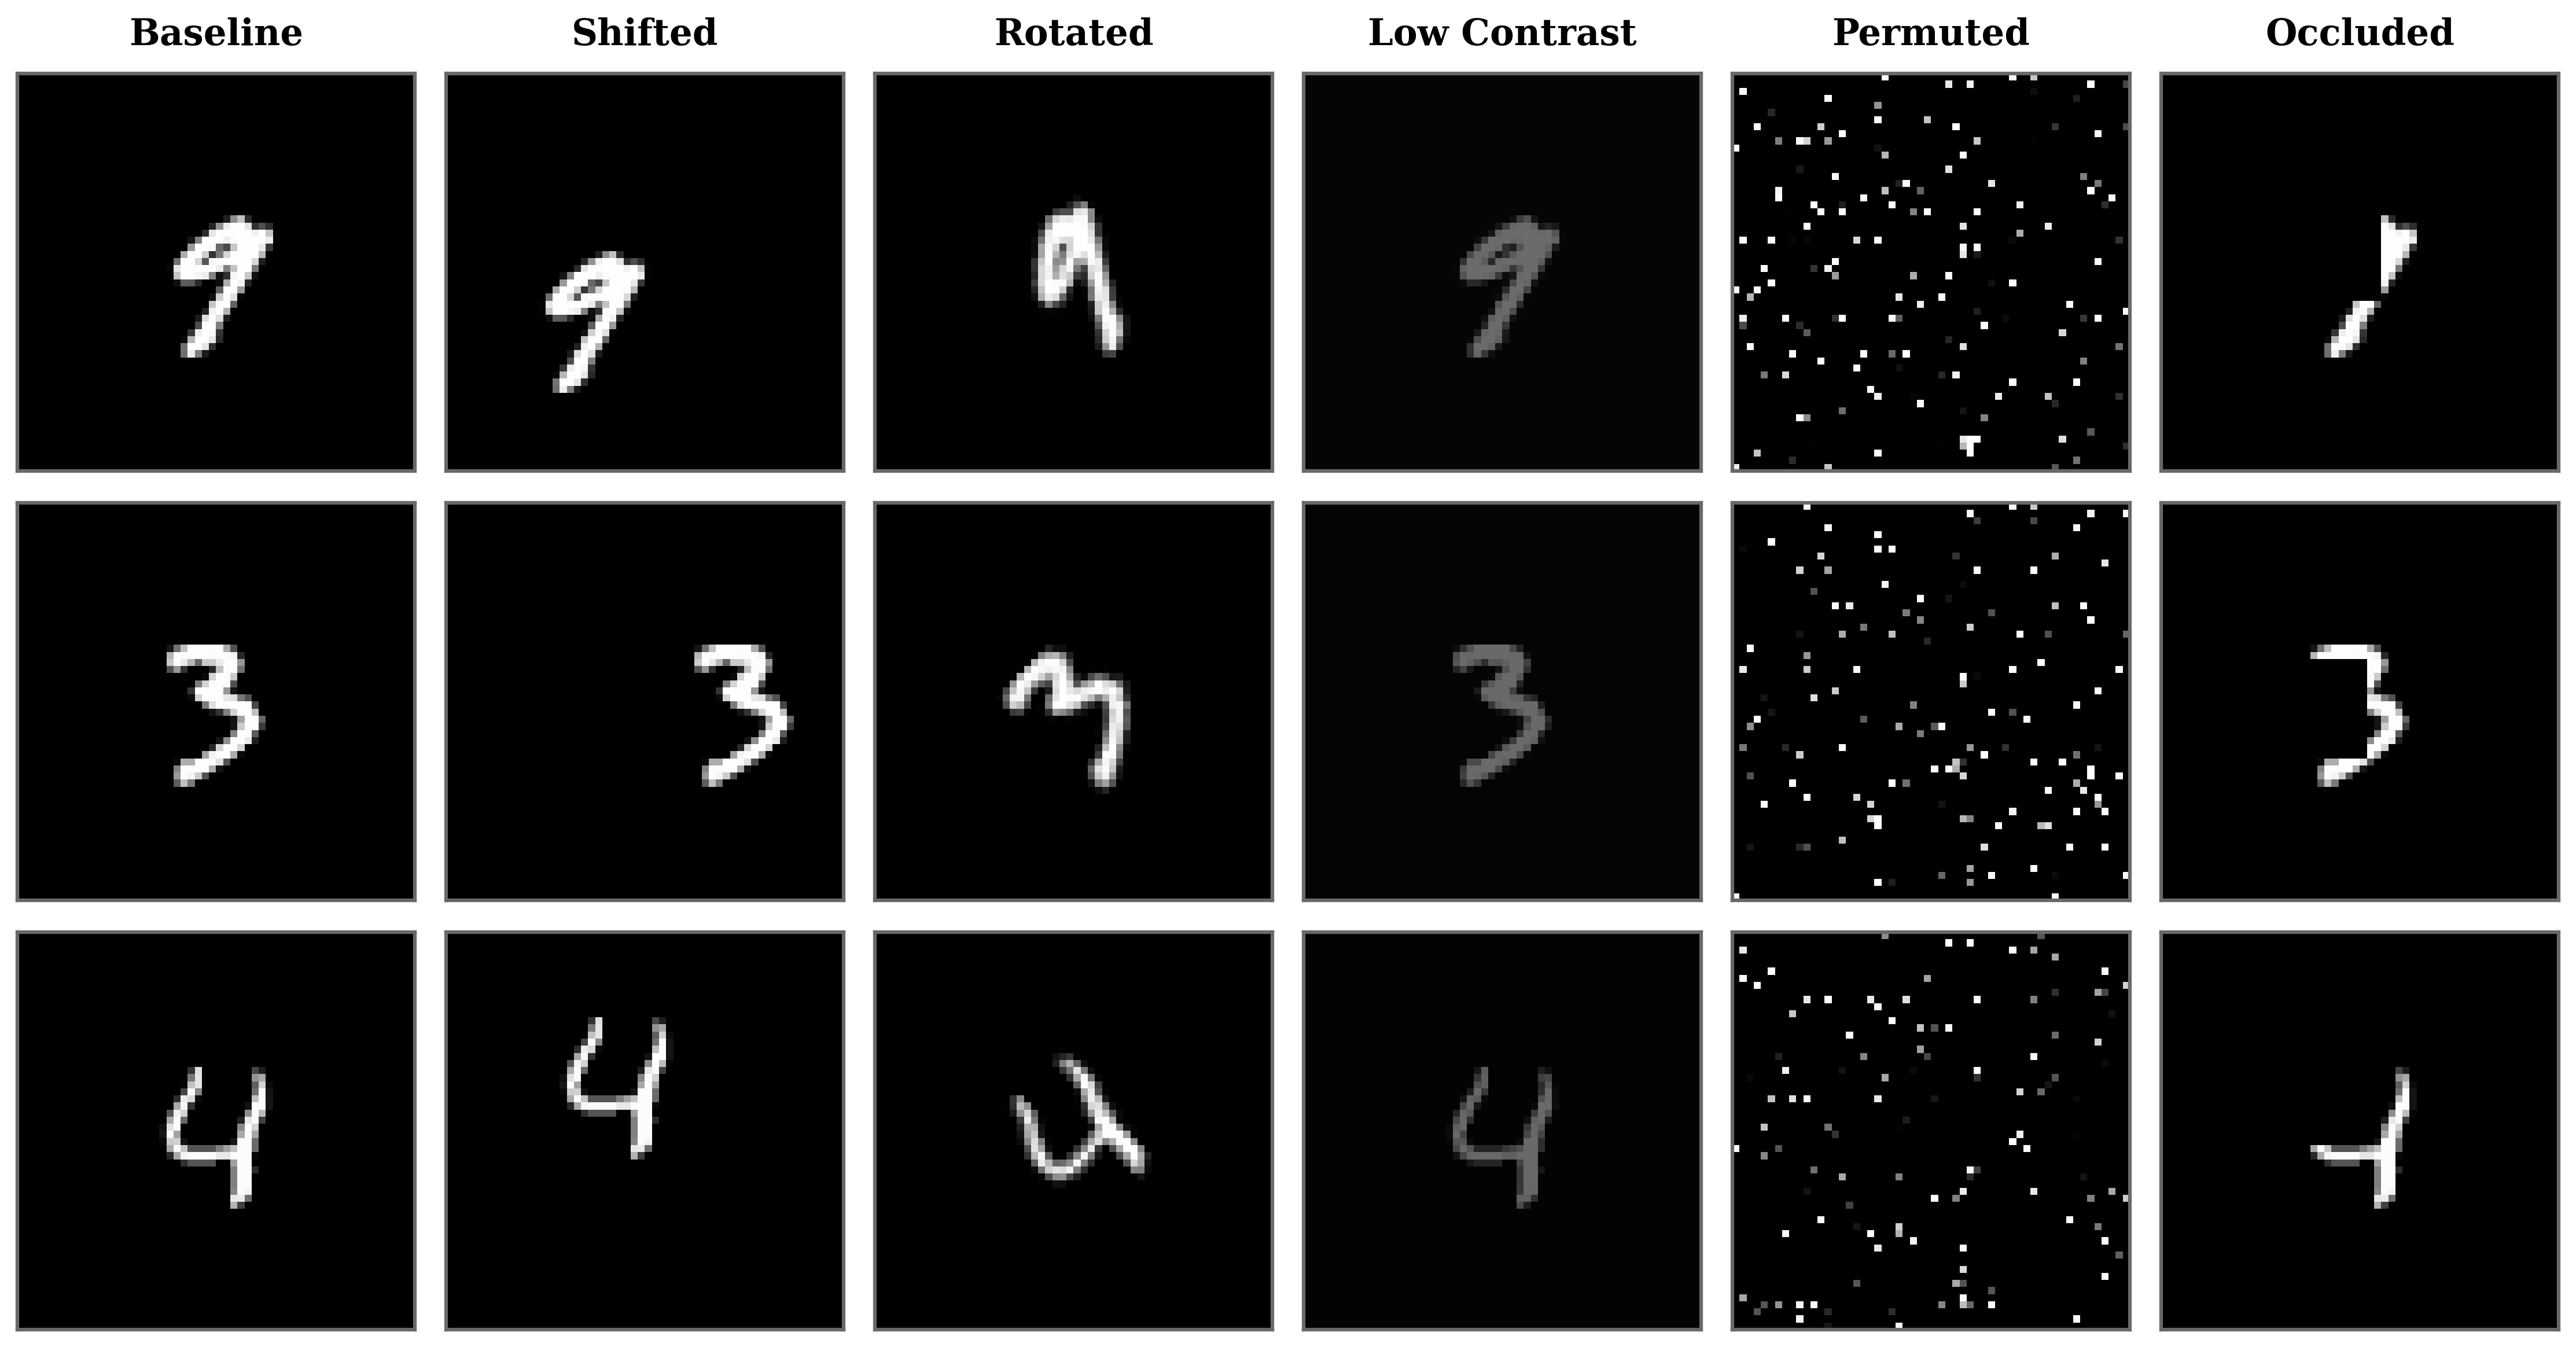

In [ ]:
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Pick specific indices from x_test that represent a 2, a 0, and a 4 for variety
sample_images = np.array([x_test[20], x_test[30], x_test[4]]) / 255.0
canvas_size = 56

# A. Baseline
baseline = create_canvas_dataset(sample_images, canvas_size, random_shift=False)

# B. Shifted
np.random.seed(42)
shifted = create_canvas_dataset(sample_images, canvas_size, random_shift=True)

# C. Rotated
rotated = apply_rotation(baseline, angle=45)

# D. Contrast
contrast = apply_contrast(baseline, alpha=0.4)

# E. Permuted
permuted = apply_permutation(baseline.reshape(-1, canvas_size*canvas_size)).reshape(-1, canvas_size, canvas_size)

# F. Occluded
occluded = baseline.copy()
np.random.seed(24)
patch_size = 14

for img in occluded:
    # Restrict random choice to the center so the black patch actually hits the digit
    x = np.random.randint(15, canvas_size - patch_size - 15)
    y = np.random.randint(15, canvas_size - patch_size - 15)
    img[y:y+patch_size, x:x+patch_size] = 0

conditions = ['Baseline', 'Shifted', 'Rotated', 'Low Contrast', 'Permuted', 'Occluded']
data = [baseline, shifted, rotated, contrast, permuted, occluded]

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
})

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row in range(3):
    for col in range(6):
        ax = axes[row, col]

        # Use vmin=0 and vmax=1 so the contrast change is rendered accurately by matplotlib
        ax.imshow(data[col][row], cmap='gray', vmin=0, vmax=1)

        # Add a subtle border to define the 56x56 canvas clearly
        for spine in ax.spines.values():
            spine.set_edgecolor('dimgray')
            spine.set_linewidth(1.5)

        ax.set_xticks([])
        ax.set_yticks([])

        # Column Titles on the top row
        if row == 0:
            ax.set_title(conditions[col], fontsize=15, fontweight='bold', pad=12)

plt.tight_layout()

plt.savefig("spatial_stress_visualization_expanded.pdf", bbox_inches='tight', dpi=300)
plt.show()

# Learning Curve

In [ ]:

def run_scaling_analysis():
    print("Loading MNIST Data...")
    (x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

    # 2A. Pre-compute Test Data (Fixed size to ensure fair comparison)
    print("Pre-computing Test Stress Matrix and CNN Features...")
    test_samples, canvas = 500, 56
    x_test = x_test_full[:test_samples] / 255.0
    y_test = y_test_full[:test_samples]

    X_test_base = create_canvas_dataset(x_test, canvas, random_shift=False)

    test_conds = {
        'Baseline': X_test_base,
        'Shifted': create_canvas_dataset(x_test, canvas, random_shift=True),
        'Rotated': apply_rotation(X_test_base, angle=45),
        'Low Contrast': apply_contrast(X_test_base, alpha=0.4),
        'Permuted': apply_permutation(X_test_base.reshape(-1, canvas*canvas)).reshape(-1, canvas, canvas),
        'Occluded': apply_occlusion(X_test_base)
    }

    test_features = {cond: get_custom_cnn_features(data) for cond, data in test_conds.items()}
    flat_dim = canvas * canvas

    models_to_track = [
        'CNN (Native)',
        'XGBoost (Raw)', 'LightGBM (Raw)', 'CatBoost (Raw)',
        'XGBoost (CNN Feat)', 'LightGBM (CNN Feat)', 'CatBoost (CNN Feat)'
    ]

    scaling_results = {model: {cond: [] for cond in test_conds.keys()} for model in models_to_track}

    train_sizes = [1000, 3000, 6000, 10000]

    for size in train_sizes:
        print(f"\n{'='*40}\nRUNNING EXPERIMENT FOR N = {size}\n{'='*40}")

        # Prepare Train Data
        x_train = x_train_full[:size] / 255.0
        y_train = y_train_full[:size]
        X_train_base = create_canvas_dataset(x_train, canvas, random_shift=False)
        X_train_flat = X_train_base.reshape(-1, flat_dim)
        X_train_features = get_custom_cnn_features(X_train_base)

        # --- Train Native CNN ---
        print(f"Training CNN (Native) on {size} samples...")
        cnn_model = Sequential([
            Conv2D(32, (3,3), padding='Same', activation='relu', input_shape=(canvas, canvas, 1)),
            MaxPool2D((2,2)),
            Conv2D(64, (3,3), padding='Same', activation='relu'),
            MaxPool2D((2,2)),
            Conv2D(128, (3,3), padding='Same', activation='relu'),
            GlobalAveragePooling2D(),
            Dense(10, activation="softmax")
        ])
        cnn_model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        # Adjust epochs dynamically: fewer samples need more epochs to converge, large datasets need fewer
        epochs_to_run = 15 if size <= 3000 else 8
        cnn_model.fit(X_train_base.reshape(-1, canvas, canvas, 1), y_train, epochs=epochs_to_run, verbose=0)

        for cond_name, X_test in test_conds.items():
            _, acc = cnn_model.evaluate(X_test.reshape(-1, canvas, canvas, 1), y_test, verbose=0)
            scaling_results['CNN (Native)'][cond_name].append(acc)

        # --- Train Raw GBDTs ---
        print(f"Training Raw GBDTs on {size} samples...")
        gbdts_raw = {
            'XGBoost (Raw)': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist', n_jobs=-1),
            'LightGBM (Raw)': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1, n_jobs=-1),
            'CatBoost (Raw)': CatBoostClassifier(n_estimators=100, learning_rate=0.1, verbose=0, thread_count=-1)
        }
        for name, model in gbdts_raw.items():
            model.fit(X_train_flat, y_train)
            for cond_name, X_test in test_conds.items():
                acc = accuracy_score(y_test, model.predict(X_test.reshape(-1, flat_dim)))
                scaling_results[name][cond_name].append(acc)

        # --- Train Hybrid GBDTs ---
        print(f"Training Hybrid GBDTs on {size} samples...")
        gbdts_hybrid = {
            'XGBoost (CNN Feat)': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist', n_jobs=-1),
            'LightGBM (CNN Feat)': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1, n_jobs=-1),
            'CatBoost (CNN Feat)': CatBoostClassifier(n_estimators=100, learning_rate=0.1, verbose=0, thread_count=-1)
        }
        for name, model in gbdts_hybrid.items():
            model.fit(X_train_features, y_train)
            for cond_name in test_conds.keys():
                acc = accuracy_score(y_test, model.predict(test_features[cond_name]))
                scaling_results[name][cond_name].append(acc)

    return scaling_results, train_sizes, list(test_conds.keys())

# Execute the scaling analysis
scaling_results, train_sizes, condition_names = run_scaling_analysis()
print("\nScaling Analysis Complete!")

def plot_learning_curves(results, sizes, conditions):
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13,
        'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
    })

    color_map = {
        'CNN (Native)': '#404040',
        'XGBoost (Raw)': '#B2182B', 'LightGBM (Raw)': '#D6604D', 'CatBoost (Raw)': '#F4A582',
        'XGBoost (CNN Feat)': '#2166AC', 'LightGBM (CNN Feat)': '#4393C3', 'CatBoost (CNN Feat)': '#92C5DE'
    }

    # Mapping line styles: solid for CNN, dashed for Raw, dashdot for Hybrid
    ls_map = {
        'CNN (Native)': '-',
        'XGBoost (Raw)': '--', 'LightGBM (Raw)': '--', 'CatBoost (Raw)': '--',
        'XGBoost (CNN Feat)': '-.', 'LightGBM (CNN Feat)': '-.', 'CatBoost (CNN Feat)': '-.'
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, cond in enumerate(conditions):
        ax = axes[i]
        for model_name, model_results in results.items():
            # Convert accuracy to percentage for plotting
            acc_percentage = [val * 100 for val in model_results[cond]]
            ax.plot(sizes, acc_percentage,
                    label=model_name,
                    color=color_map[model_name],
                    linestyle=ls_map[model_name],
                    marker='o', markersize=5, linewidth=2, alpha=0.8)

        ax.set_title(f"Test Condition: {cond}", weight='bold')
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.set_ylim(0, 105)

        # Only set X and Y labels on the outer axes
        if i % 3 == 0:
            ax.set_ylabel('Accuracy (%)', weight='bold')
        if i >= 3:
            ax.set_xlabel('Training Set Size (N)', weight='bold')
            ax.set_xticks(sizes)

    # Master title and shared legend
    plt.suptitle("Learning Curves: Impact of Data Scale on Spatial and Intensity Robustness",
                 fontsize=18, fontweight='bold', y=1.05)

    # Extract one set of handles/labels for the global legend
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, fontsize=12)

    plt.tight_layout()
    plt.savefig('Phase_5_Learning_Curves.pdf')
    plt.show()

plot_learning_curves(scaling_results, train_sizes, condition_names)

Loading MNIST Data...
Pre-computing Test Stress Matrix and CNN Features...

RUNNING EXPERIMENT FOR N = 1000
Training CNN (Native) on 1000 samples...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Raw GBDTs on 1000 samples...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Training Hybrid GBDTs on 1000 samples...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


RUNNING EXPERIMENT FOR N = 3000
Training CNN (Native) on 3000 samples...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Raw GBDTs on 3000 samples...


KeyboardInterrupt: 